# **Customer Churn Analysis and Prediction**

## **TASK 1: Data Cleaning and Preprocessing**

### **Data Understand**

In [ ]:
# import library
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Load dataset
churn_data = pd.read_csv('/content/Telco_Customer_Churn_Dataset .csv')

**Inspect Basic Info**

In [ ]:
# Inspect Basic Info
churn_data.head()

# Shape of the dataset(row,columns)
churn_data.shape

# data types for all columns
churn_data.dtypes

# Dataset Columns
churn_data.columns
print(churn_data.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


**Remove Spaces**

In [ ]:
# Clean Column Names
churn_data.columns = churn_data.columns.str.strip()
print(churn_data.columns.tolist())


['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


**Summary of statistics**

In [ ]:
# Summary Stats
churn_data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### **Data Cleaning**

**Handle Missing Values**

In [ ]:
# Check missing values
churn_data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
# Converts text → numeric
churn_data['TotalCharges'] = pd.to_numeric(churn_data['TotalCharges'], errors='coerce')


In [ ]:
# Handle Missing values in Total Charges
print("Missing values:", churn_data['TotalCharges'].isna().sum())

# Fill with median
churn_data['TotalCharges'] = churn_data['TotalCharges'].fillna(
    churn_data['TotalCharges'].median()
)

print("After filling:", churn_data['TotalCharges'].isna().sum())


Missing values: 11
After filling: 0


**Drop columns**

In [ ]:
# Drop Irrelevant Columns
# churn_data.drop(columns=["customerID"],inplace = True)

In [ ]:
# Standardize categorical columns with "No internet/phone service"
cols_to_replace = ['OnlineSecurity','OnlineBackup','DeviceProtection',
                   'TechSupport','StreamingTV','StreamingMovies','MultipleLines']
for col in cols_to_replace:
    churn_data[col] = churn_data[col].replace({'No internet service':'No', 'No phone service':'No'})

**Convert target Variable**

In [ ]:
# Convert Target Variable (Churn)
churn_data['Churn'] = churn_data['Churn'].map({'Yes': 1, 'No': 0})

**Encode Categorical Variables**

In [ ]:
# Copy original data for some reasons
churn_data = churn_data.copy()

In [ ]:
#  One-Hot Encoding for Categorical Features
churn_data_encode = pd.get_dummies(churn_data, drop_first=True)


In [ ]:
# Scale numerical features (optional but recommended for ML)
scaler = StandardScaler()
num_cols = ['tenure','MonthlyCharges','TotalCharges']
churn_data[num_cols] = scaler.fit_transform(churn_data[num_cols])

**Cleaned Data**

In [ ]:
# Clean Data
print(churn_data.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   float64
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## **TASK 2: Exploratory Data Analysis (EDA)**

In [ ]:
# import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='white')
plt.rcParams['figure.figsize'] = (8,5)


**1. Overall Churn Rate**

In [ ]:
# Calculate Churn Rate
churn_rate = churn_data['Churn'].value_counts(normalize=True) * 100
print(churn_rate)

Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


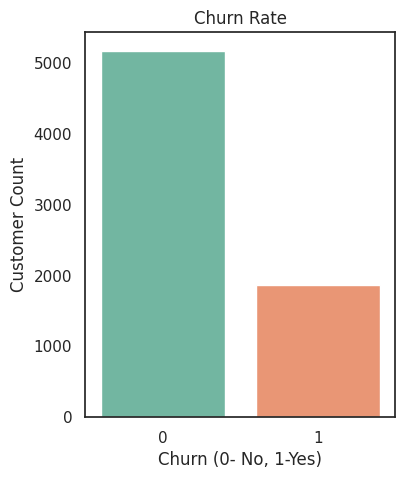

In [ ]:
# Visualize Churn Rate
plt.figure(figsize=(4,5)) # Set figure size
sns.countplot(x='Churn', data=churn_data, hue='Churn', palette='Set2',legend=False)
plt.title("Churn Rate")
plt.xlabel("Churn (0- No, 1-Yes)")
plt.ylabel("Customer Count")
plt.show() #Insight: Shows the proportion of customers who churned vs stayed.

**2. Explore Customer Distribution by Various Demographics.**

Insight: Helps identify demographic groups with higher churn risk.

**Churn by Gender**

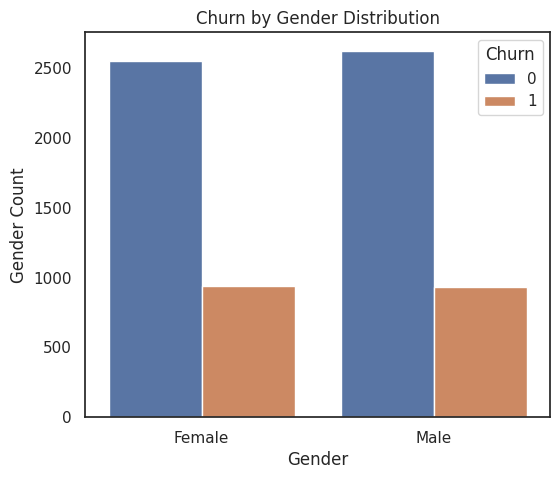

In [ ]:
# Gender Distribution
plt.figure(figsize=(6,5))
sns.countplot(x='gender', hue='Churn', data=churn_data ,legend=True)
plt.title("Churn by Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Gender Count")
plt.show()

**Churn by SeniorCitizen**

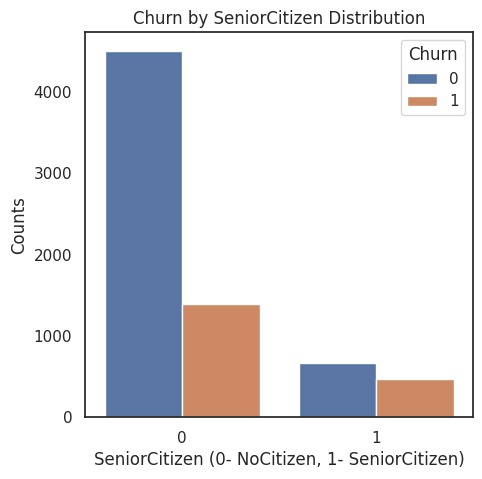

In [ ]:
# SeniorCitizen Distribution
plt.figure(figsize=(5,5))
sns.countplot(x='SeniorCitizen', hue='Churn', data=churn_data ,legend=True)
plt.title("Churn by SeniorCitizen Distribution")
plt.xlabel("SeniorCitizen (0- NoCitizen, 1- SeniorCitizen)")
plt.ylabel("Counts")
plt.show()

**Churn by Parnet**

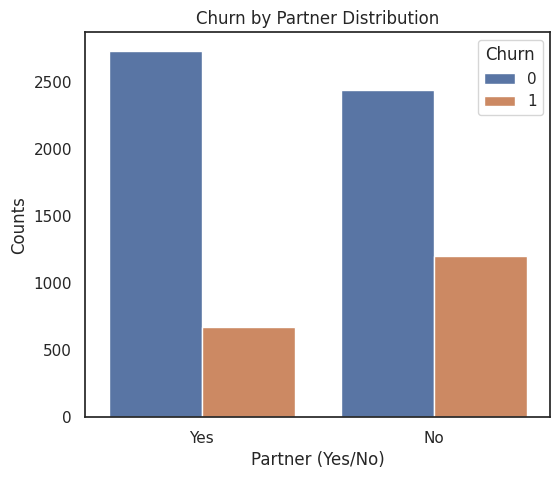

In [ ]:
# Partner Status
plt.figure(figsize=(6,5))
sns.countplot(x='Partner', hue='Churn', data=churn_data ,legend=True)
plt.title("Churn by Partner Distribution")
plt.xlabel("Partner (Yes/No)")
plt.ylabel("Counts")
plt.show()

**3.** **Analyze Tenure Distribution**

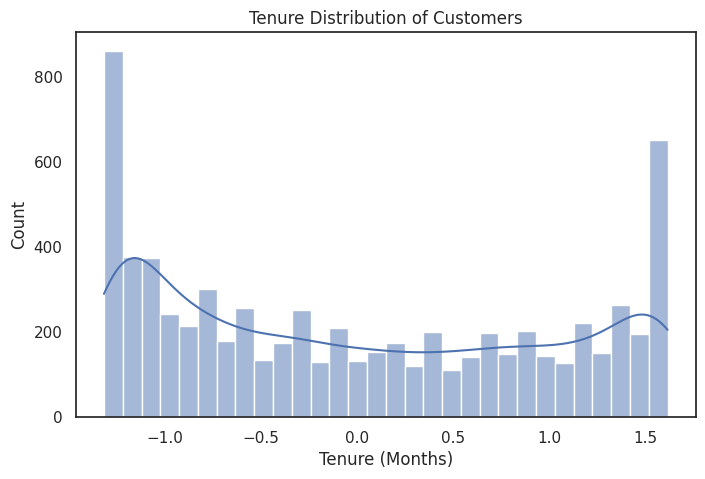

In [ ]:
# Tenure Distribution
sns.histplot(churn_data['tenure'], bins=30, kde=True)
plt.title('Tenure Distribution of Customers')
plt.xlabel('Tenure (Months)')
plt.show()


**Tenure vs Churn**

Customers with shorter tenure tend to churn more.

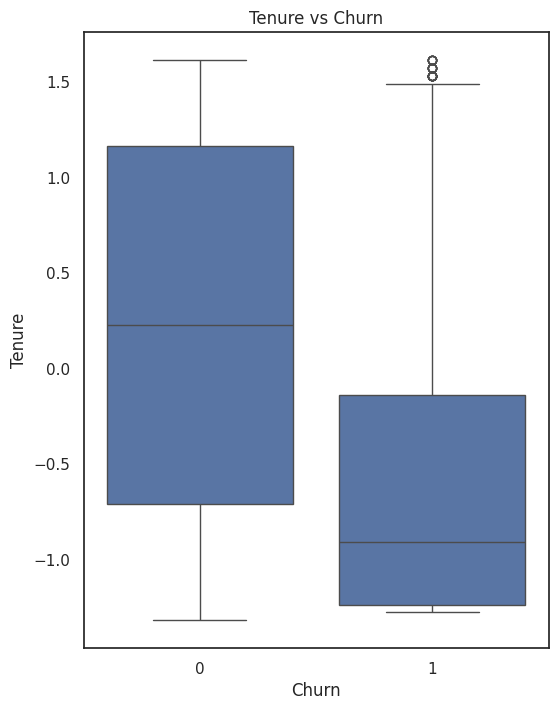

In [ ]:
plt.figure(figsize=(6,8))
sns.boxplot(x='Churn', y='tenure', data=churn_data)
plt.title('Tenure vs Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure')
plt.show()


**Churn vs Contract Type**

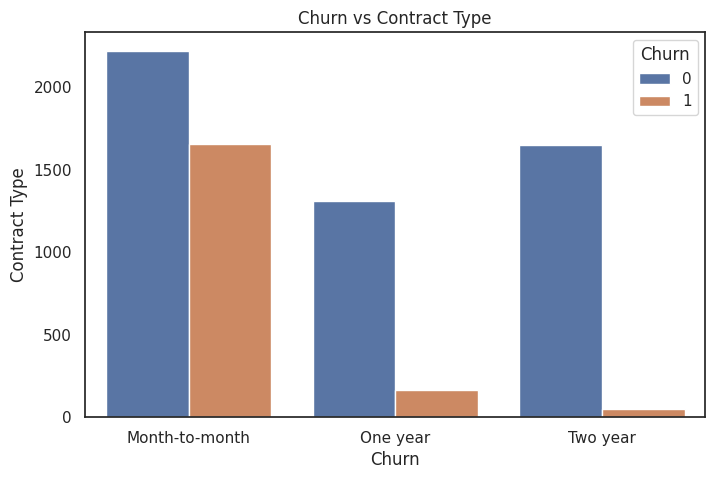

In [ ]:
# Insight: Month-to-month contracts usually show higher churn.
sns.countplot(x='Contract', hue='Churn',data=churn_data)
plt.title('Churn vs Contract Type')
plt.xlabel('Churn')
plt.ylabel('Contract Type')
plt.show()

**Churn vs Payment Method**

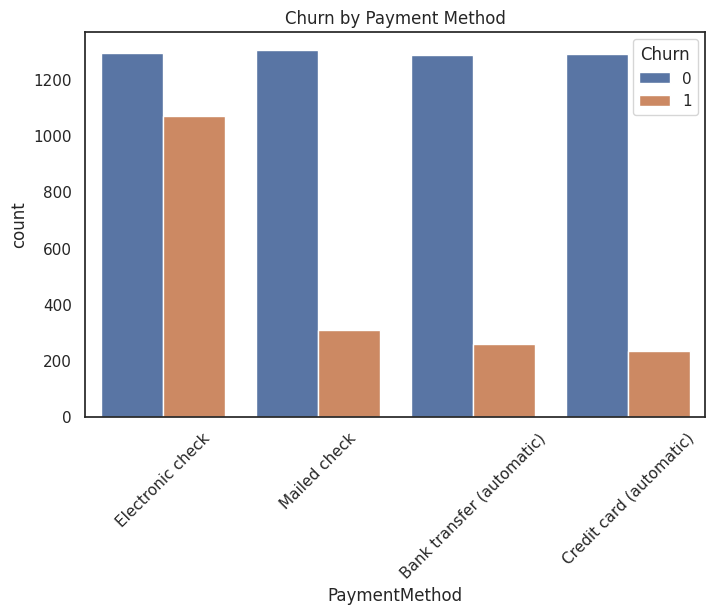

In [ ]:
# Electronic check users often show higher churn rates.
sns.countplot(x='PaymentMethod', hue='Churn', data=churn_data)
plt.title('Churn by Payment Method')
plt.xticks(rotation=45)
plt.show()


**Monthly Charges vs Churn**

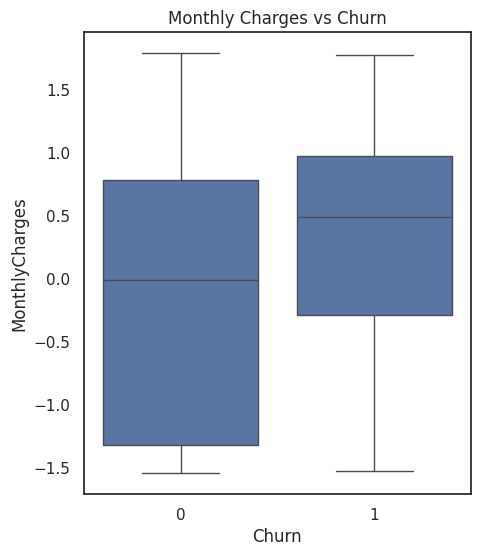

In [ ]:
plt.figure(figsize=(5,6))
sns.boxplot(x='Churn', y='MonthlyCharges', data=churn_data)
plt.title('Monthly Charges vs Churn')
plt.show()


**Summary of EDA Findings**

1. Overall churn rate indicates a significant imbalance between churned and retained customers.
2. Senior citizens and customers without partners show higher churn.
3. Customers with shorter tenure are more likely to churn.
4. Month-to-month contracts have the highest churn rate.
5. Electronic check payment method is strongly associated with churn.
6. Higher monthly charges are linked to increased churn.

### **TASK 3: Customer Segmentation**

**Segment by Tenure**

In [ ]:
# Tenure Segmentation based on quartiles
churn_data['TenureSegment'] = pd.qcut(
    churn_data['tenure'],
    q=4,  # divide into 4 equal groups
    labels=['New', 'MidTerm', 'LongTerm', 'VeryLong']
)

# MonthlyCharges Segmentation based on quartiles
churn_data['MonthlychargesSegment'] = pd.qcut(
    churn_data['MonthlyCharges'],
    q=4,  # divide into 4 equal groups
    labels=['Low', 'Medium', 'High', 'VeryHigh']
)

churn_data['ContractSegment'] = churn_data['Contract'].str.replace("-", " ", regex=False)


In [ ]:
churn_data[['TenureSegment', 'MonthlychargesSegment', 'ContractSegment']].isna().sum()


,0
TenureSegment,0
MonthlychargesSegment,0
ContractSegment,0


In [ ]:
churn_data['CustomerSegment'] = (
    churn_data['TenureSegment'].astype(str) + "_" +
    churn_data['MonthlychargesSegment'].astype(str) + "_" +
    churn_data['ContractSegment'].astype(str)
)
churn_data[['customerID', 'CustomerSegment']].head(10)

,customerID,CustomerSegment
0,7590-VHVEG,New_Low_Month to month
1,5575-GNVDE,LongTerm_Medium_One year
2,3668-QPYBK,New_Medium_Month to month
3,7795-CFOCW,LongTerm_Medium_One year
4,9237-HQITU,New_High_Month to month
5,9305-CDSKC,New_VeryHigh_Month to month
6,1452-KIOVK,MidTerm_High_Month to month
7,6713-OKOMC,MidTerm_Low_Month to month
8,7892-POOKP,MidTerm_VeryHigh_Month to month
9,6388-TABGU,VeryLong_Medium_One year


**Churn Rate Analysis Across Segments**

Churn Rate per Segment

In [ ]:
segment_churn = (churn_data.groupby('CustomerSegment').agg(TotalCustomers=('customerID', 'count'),ChurnRate=('Churn', 'mean')))
print(segment_churn)


                                  TotalCustomers  ChurnRate
CustomerSegment                                            
LongTerm_High_Month to month                 211   0.379147
LongTerm_High_One year                       126   0.126984
LongTerm_High_Two year                        58   0.017241
LongTerm_Low_Month to month                   57   0.122807
LongTerm_Low_One year                        141   0.028369
LongTerm_Low_Two year                        200   0.010000
LongTerm_Medium_Month to month               160   0.193750
LongTerm_Medium_One year                     155   0.103226
LongTerm_Medium_Two year                      75   0.026667
LongTerm_VeryHigh_Month to month             300   0.403333
LongTerm_VeryHigh_One year                   184   0.206522
LongTerm_VeryHigh_Two year                    52   0.115385
MidTerm_High_Month to month                  405   0.449383
MidTerm_High_One year                         51   0.117647
MidTerm_High_Two year                   

In [ ]:
# Tenure vs Churn
churn_data.groupby('TenureSegment')['Churn'].mean()

# Monthly Charges vs Churn
churn_data.groupby('MonthlyCharges')['Churn'].mean()

# Contract vs Churn
churn_data.groupby('Contract')['Churn'].mean()


/tmp/ipython-input-2846480187.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_data.groupby('TenureSegment')['Churn'].mean()


,Churn
Contract,
Month-to-month,0.427097
One year,0.112695
Two year,0.028319


**Summary:**

Customer segmentation was performed using tenure, monthly charges, and contract type.
Customers were grouped into meaningful segments using an RFM-inspired approach.
Churn analysis showed that new customers on month-to-month contracts with high charges have the highest churn rates, while long-term customers with longer contracts exhibit strong retention.

## **TASK 4: Churn Prediction Model**

In [ ]:
from sklearn .model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report

**Feature Selection & Train-Test Split**

In [ ]:
X =churn_data.drop(['customerID','Churn'],axis=1)
y = churn_data['Churn']

# Onehot encoding
X = pd.get_dummies(X, drop_first=True)

# Split data
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify = y)
print(X)

# CConfirm datasize
print("Total rows after cleaning:", len(churn_data))
print("Train set size:", len(X_train))
print("Test set size:", len(X_test))



      SeniorCitizen    tenure  MonthlyCharges  TotalCharges  gender_Male  \
0                 0 -1.277445       -1.160323     -0.994242        False   
1                 0  0.066327       -0.259629     -0.173244         True   
2                 0 -1.236724       -0.362660     -0.959674         True   
3                 0  0.514251       -0.746535     -0.194766         True   
4                 0 -1.236724        0.197365     -0.940470        False   
...             ...       ...             ...           ...          ...   
7038              0 -0.340876        0.665992     -0.128655         True   
7039              0  1.613701        1.277533      2.243151        False   
7040              0 -0.870241       -1.168632     -0.854469        False   
7041              1 -1.155283        0.320338     -0.872062         True   
7042              0  1.369379        1.358961      2.014288         True   

      Partner_Yes  Dependents_Yes  PhoneService_Yes  MultipleLines_Yes  \
0            

In [ ]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Train Logistic Regression Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Make Predictions
y_pred = model.predict(X_test)


In [ ]:
# Find Model Performanc
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Model Performance:")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)


Model Performance:
Accuracy : 0.8026969481902059
Precision: 0.6643835616438356
Recall   : 0.5187165775401069
F1 Score : 0.5825825825825826


In [ ]:
# Confusion Matrix & Classification Report
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Confusion Matrix:
[[937  98]
 [180 194]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



## **TASK 5: Data Visualizations**

**Churn Rate by Tenure Group**

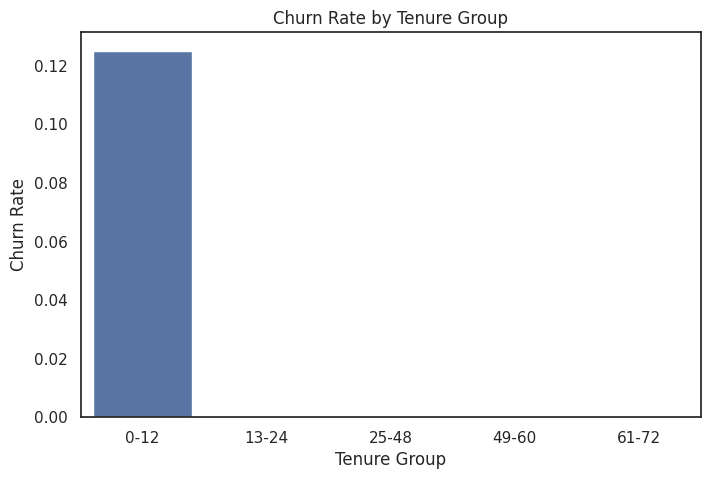

In [ ]:
# Create tenure groups
tenure_bins = [0, 12, 24, 48, 60, 72]
tenure_labels = ['0-12','13-24','25-48','49-60','61-72']

churn_data['tenure_group'] = pd.cut(
    churn_data['tenure'],
    bins=tenure_bins,
    labels=tenure_labels,
    include_lowest=True  # ensures 0 is included in first bin
)

#  Compute churn rate per tenure group
tenure_churn = churn_data.groupby('tenure_group', observed=True)['Churn'].mean().reset_index()

# Plot using seaborn
sns.barplot(data=tenure_churn, x='tenure_group', y='Churn')
plt.title("Churn Rate by Tenure Group")
plt.ylabel("Churn Rate")
plt.xlabel("Tenure Group")
plt.show()


**1. Monthly Charges vs Churn**

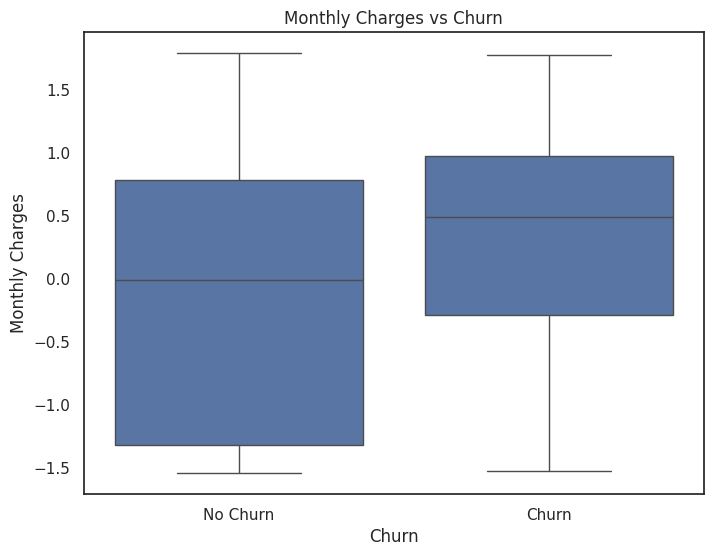

In [ ]:

# -----------------------------
# Monthly Charges vs Churn
# -----------------------------
sns.set(style="white")
plt.rcParams['figure.figsize'] = (8,6)

plt.figure()
sns.boxplot(x='Churn', y='MonthlyCharges', data=churn_data)
plt.xticks([0,1], ['No Churn','Churn'])
plt.title("Monthly Charges vs Churn")
plt.ylabel("Monthly Charges")
plt.show()


**2. Numerical Features vs Churn**

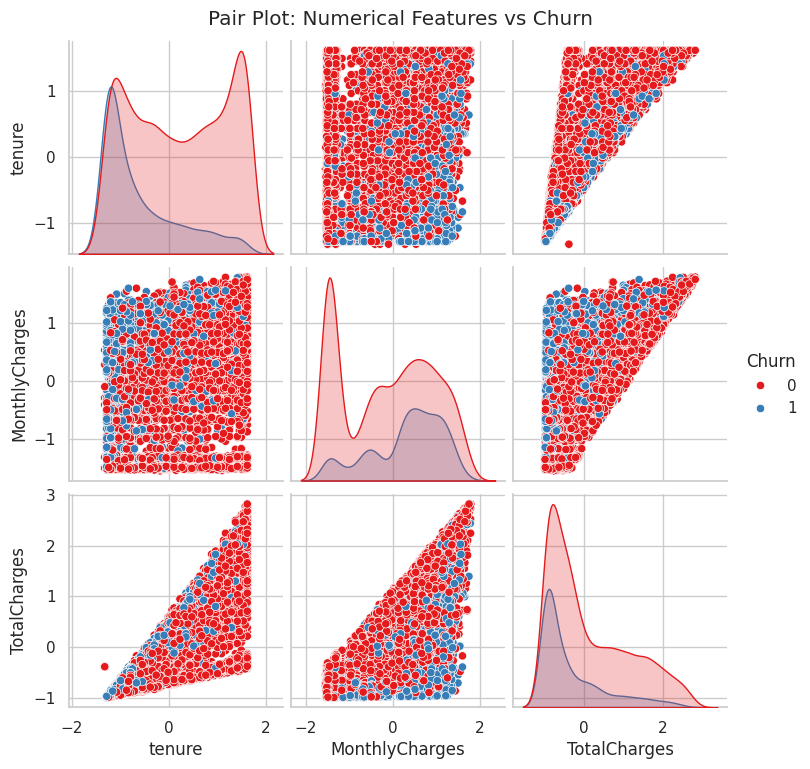

In [ ]:
# -----------------------------
# Pair Plot: Numerical Features vs Churn
# -----------------------------
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
sns.pairplot(churn_data[numerical_features], hue='Churn', palette='Set1')
plt.suptitle("Pair Plot: Numerical Features vs Churn", y=1.02)
plt.show()


**3. Churn Count by Contract Type**

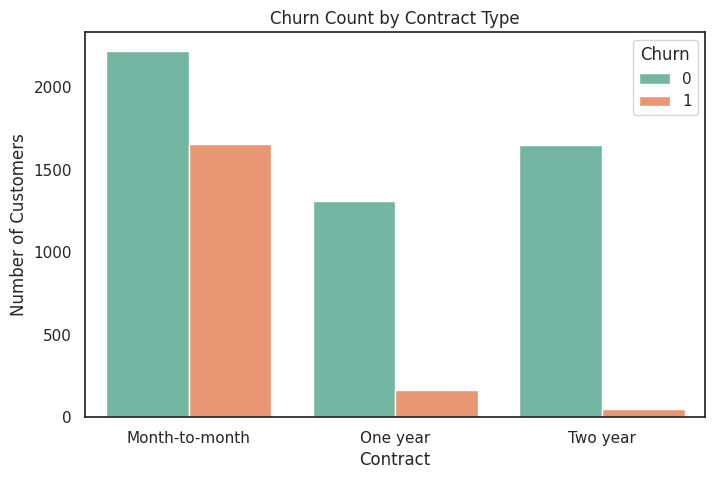

In [ ]:
# -----------------------------
# Count Plot: Churn by Contract Type
# -----------------------------
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn', data=churn_data, palette='Set2')
plt.title("Churn Count by Contract Type")
plt.ylabel("Number of Customers")
plt.show()

**4. Churn Rate by Payment Method**

<Figure size 800x500 with 0 Axes>

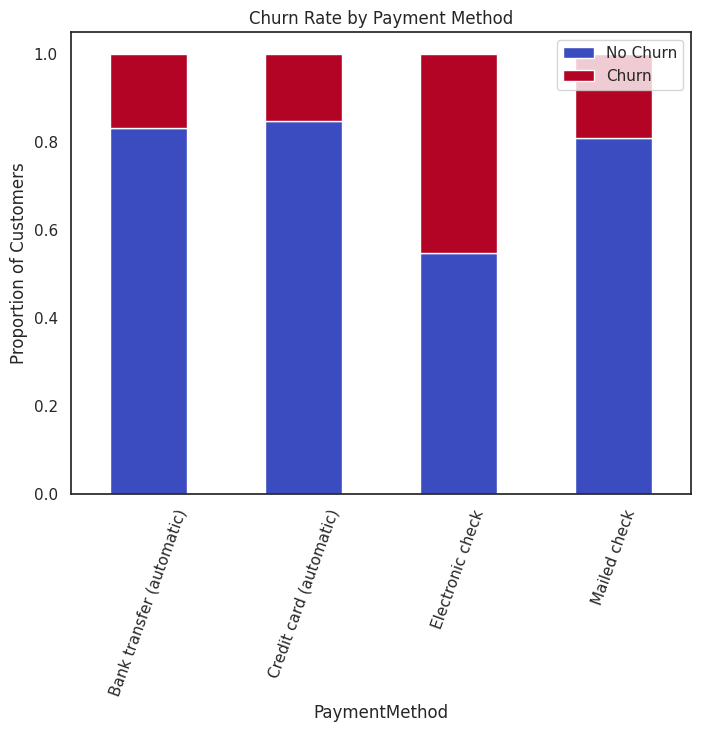

In [ ]:
# -----------------------------
# Payment Method vs Churn
# -----------------------------
plt.figure(figsize=(8,5))
payment_churn = pd.crosstab(churn_data['PaymentMethod'], churn_data['Churn'], normalize='index')
payment_churn.plot(kind='bar', stacked=True, colormap='coolwarm')
plt.title("Churn Rate by Payment Method")
plt.ylabel("Proportion of Customers")
plt.legend(['No Churn','Churn'], loc='upper right')
plt.xticks(rotation=70)
plt.show()

**5. Tenure Distribution by Churn**

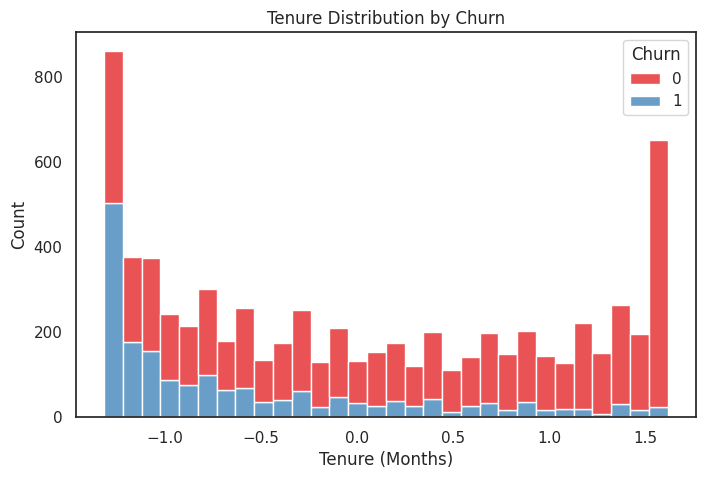

In [ ]:
# -----------------------------
# Histogram: Distribution of Tenure
# -----------------------------
plt.figure(figsize=(8,5))
sns.histplot(churn_data, x='tenure', bins=30, hue='Churn', multiple='stack', palette='Set1')
plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (Months)")
plt.show()



**6. LTV Distribution of High-Value Customers at Risk of Churn**

High-Value Customers: 1761
High-Value Customers at Risk of Churn: 255


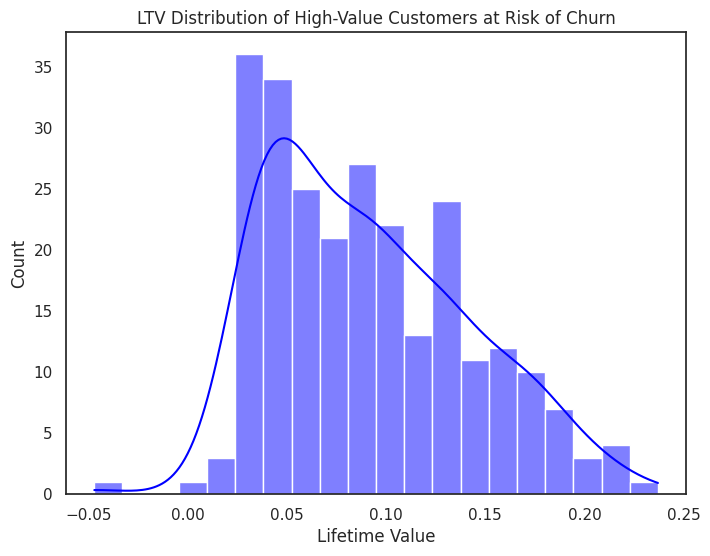

In [ ]:
# -----------------------------
# High-Value Customers at Risk (Top 25% TotalCharges)
# -----------------------------
churn_data['LTV'] = churn_data['MonthlyCharges'] * (churn_data['tenure']/12)
high_value_customers = churn_data[churn_data['TotalCharges'] > churn_data['TotalCharges'].quantile(0.75)]
high_value_risk = high_value_customers[high_value_customers['Churn'] == 1]

print("High-Value Customers:", len(high_value_customers))
print("High-Value Customers at Risk of Churn:", len(high_value_risk))

# Visualize LTV distribution
plt.figure()
sns.histplot(high_value_risk['LTV'], bins=20, kde=True, color='blue')
plt.title("LTV Distribution of High-Value Customers at Risk of Churn")
plt.xlabel("Lifetime Value")
plt.show()